# MARKET CAMPAIGN ANALYSIS

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [5]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


There is no need to fill the spaces as fortunately there are no null values in it otherwise I will use Imputer function here to fill the values like most frequent and median.

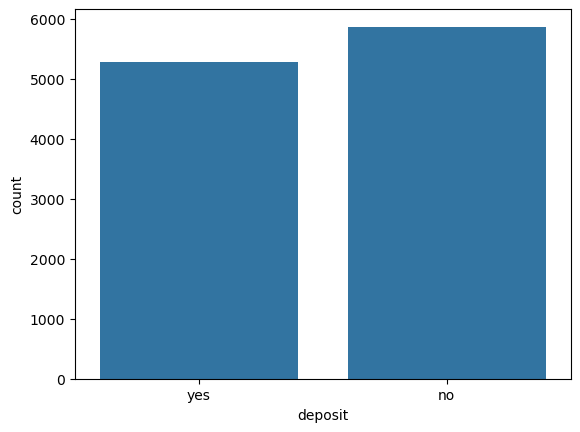

In [6]:
# deposit counts 
sns.countplot(x="deposit",data=df)
plt.show()

<Axes: xlabel='deposit', ylabel='campaign'>

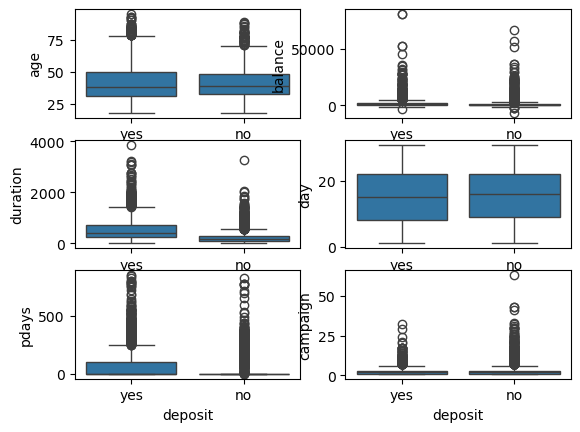

In [7]:
fig,axes=plt.subplots(3,2)
sns.boxplot(ax=axes[0,0],data=df,x="deposit",y="age")
sns.boxplot(ax=axes[0,1],data=df,x="deposit",y="balance")
sns.boxplot(ax=axes[1,0],data=df,x="deposit",y="duration")
sns.boxplot(ax=axes[1,1],data=df,x="deposit",y="day")
sns.boxplot(ax=axes[2,0],data=df,x="deposit",y="pdays")
sns.boxplot(ax=axes[2,1],data=df,x="deposit",y="campaign")

1. Here, median ages are almost similar in both the cases of deposit so it is not a strong predictor value but older customer subscribe slightly more hence still important.
2. Balnce might influence deposits but there are lot of outliers to deal . High balance customers may be more financially active.
3. Longer calls suggest more subscribers so it is a powerful predictor here.
4. Day is not a good feature as almost similar.
5. Previous days can be an important feature here but here are different spread patterns.
6. Suprisingly, lower campaign values perform better. This suggest that excessively marketing calls can reduce the effectiveness and impact.

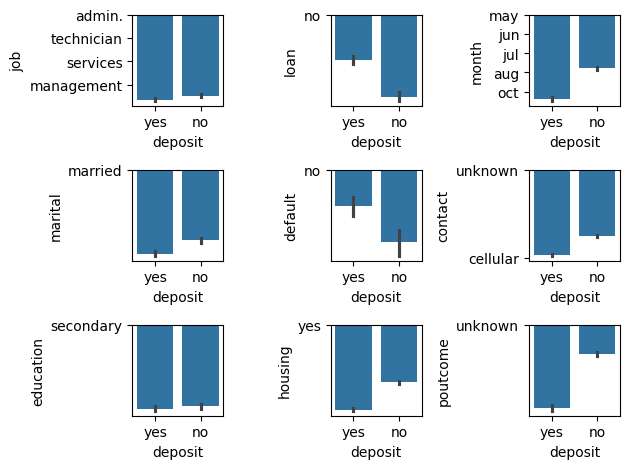

In [8]:
fig,axes=plt.subplots(3,3)
sns.barplot(ax=axes[0,0],data=df,x="deposit",y="job")
sns.barplot(ax=axes[1,0],data=df,x="deposit",y="marital")
sns.barplot(ax=axes[2,0],data=df,x="deposit",y="education")
sns.barplot(ax=axes[1,1],data=df,x="deposit",y="default")
sns.barplot(ax=axes[2,1],data=df,x="deposit",y="housing")
sns.barplot(ax=axes[0,1],data=df,x="deposit",y="loan")
sns.barplot(ax=axes[1,2],data=df,x="deposit",y="contact")
sns.barplot(ax=axes[0,2],data=df,x="deposit",y="month")
sns.barplot(ax=axes[2,2],data=df,x="deposit",y="poutcome")
plt.tight_layout()
plt.show()


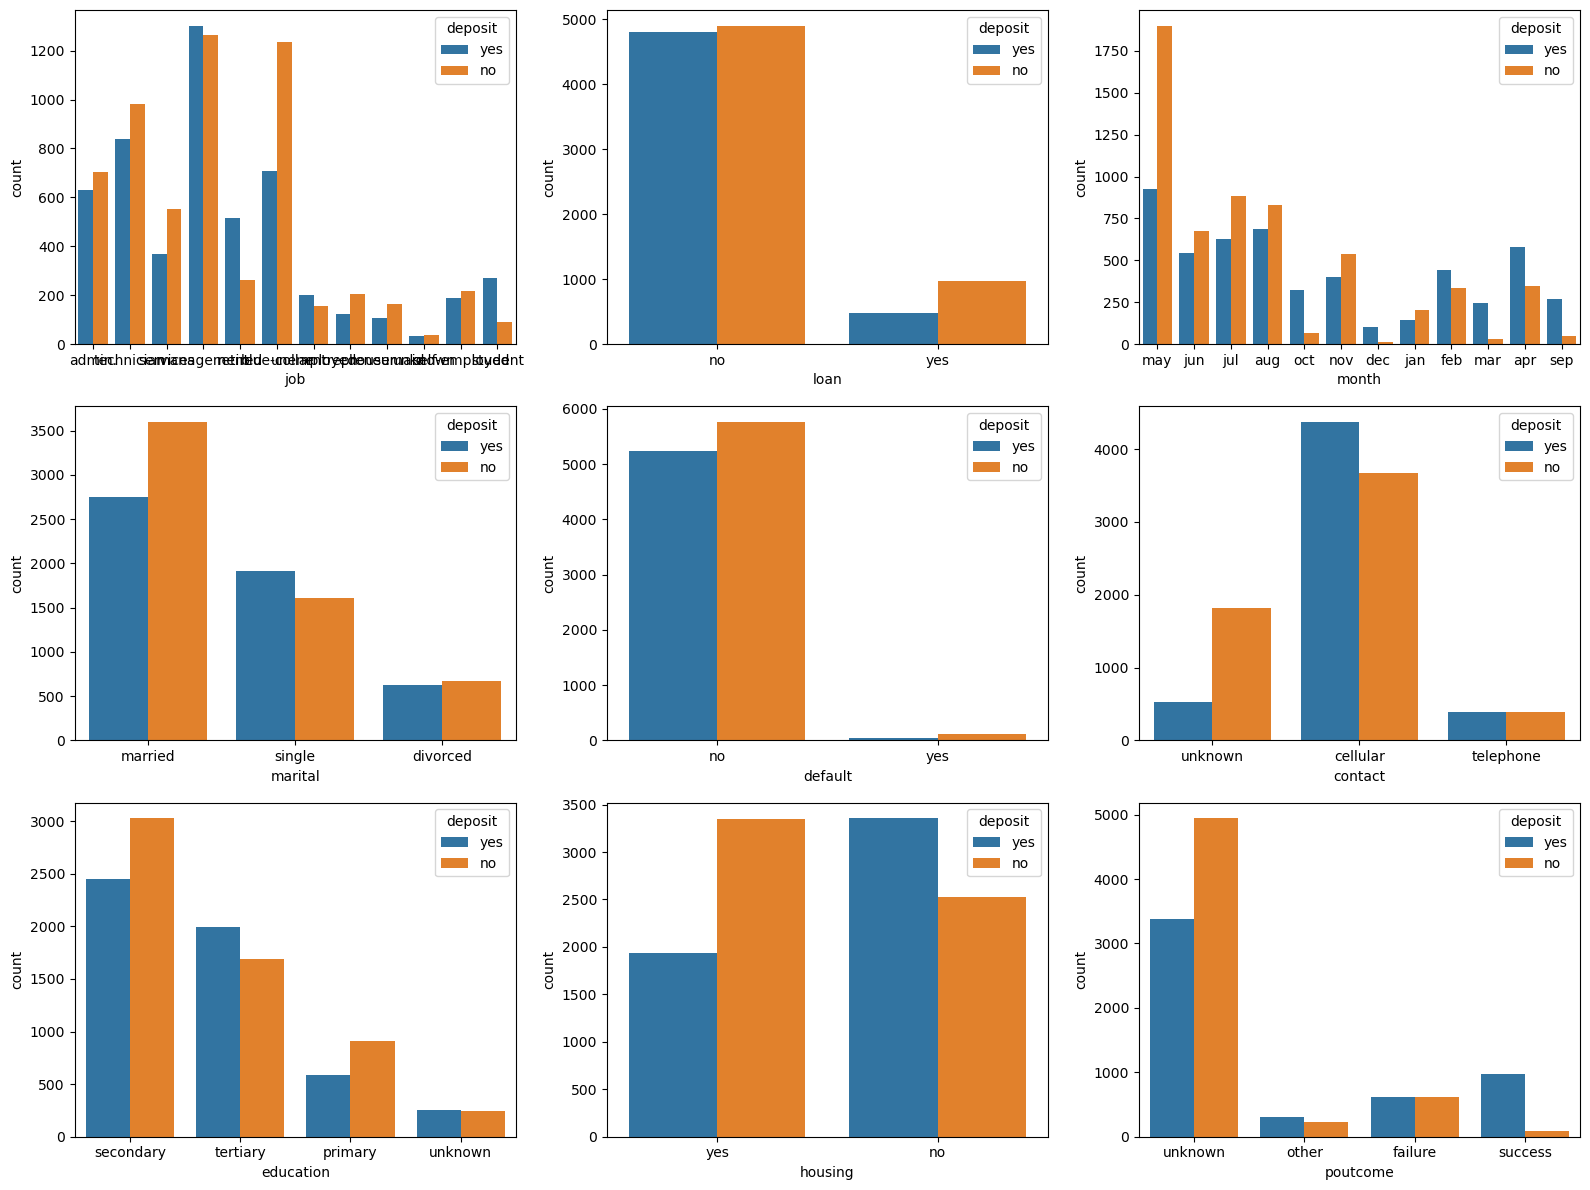

In [9]:
fig, axes = plt.subplots(3,3, figsize=(16,12))

sns.countplot(ax=axes[0,0], x="job", hue="deposit", data=df)
sns.countplot(ax=axes[0,1], x="loan", hue="deposit", data=df)
sns.countplot(ax=axes[0,2], x="month", hue="deposit", data=df)

sns.countplot(ax=axes[1,0], x="marital", hue="deposit", data=df)
sns.countplot(ax=axes[1,1], x="default", hue="deposit", data=df)
sns.countplot(ax=axes[1,2], x="contact", hue="deposit", data=df)

sns.countplot(ax=axes[2,0], x="education", hue="deposit", data=df)
sns.countplot(ax=axes[2,1], x="housing", hue="deposit", data=df)
sns.countplot(ax=axes[2,2], x="poutcome", hue="deposit", data=df)

plt.tight_layout()
plt.show()

1. job affects deposit  subscription behavior so it is an important feature.
2. customer without personal loans subscribe more.
3. May have huge impact so here timings also matters a lot.
4. Family responsibilities here influences the financial decision.
5. It is common that if no default is there then people will have deposit so it is not a important feature too.
6. Cellular contact comparatively perform much better to reach the customers so here it is also an good feature to analyze.
7. Education level may impact on the reach of awareness.
8. Housing suggest that people already with housing loan do not afford furthur liabilities so this feature may affect too.
9. poutcome does not suggest much as unknown have higher counts with no and yes and here the success has greater yes but having less counts overall .

In [10]:
df["deposit"]=df["deposit"].map({"yes":1,"no":0})

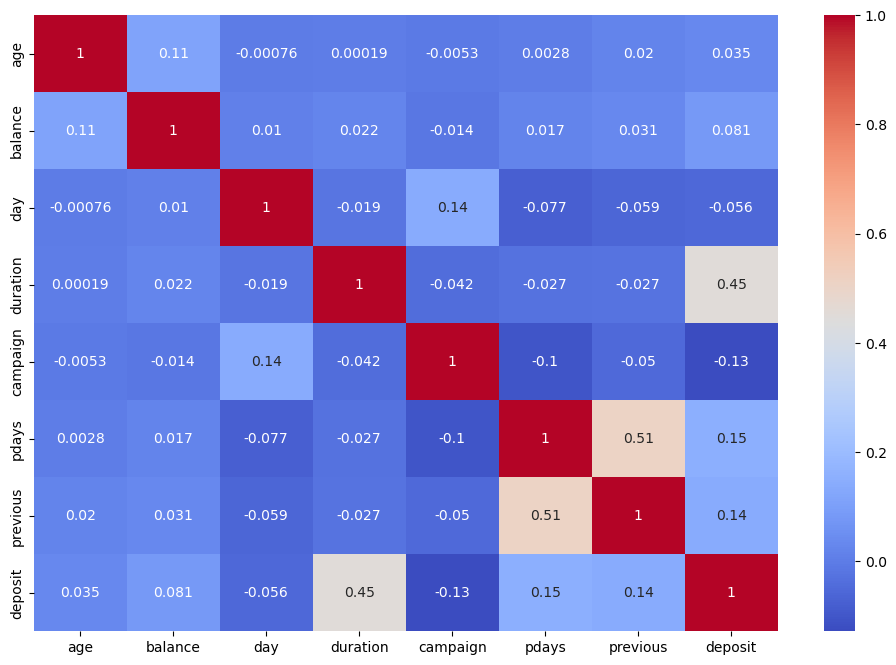

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True
)
plt.show()

1.  More campaign contacts can slightly have lower subscription chance.
2. Pdays contact history shows less impact on deposit.
3. More previous interactions slightly increase subscription probability.
4. Higher balance customers subscribe slightly more.
5. Age does not matter  much.
6. Day does not useful so it can be drop as well.
7. pdays and previous together have a strong relation so a new feature can also be added related to them.



# Classifying categorical and numerical columns 

In [12]:
numerical_cols=df.select_dtypes(include="int64").columns
categorical_cols=df.select_dtypes(include="object").columns

In [13]:
numerical_cols

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'deposit'],
      dtype='object')

In [14]:
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

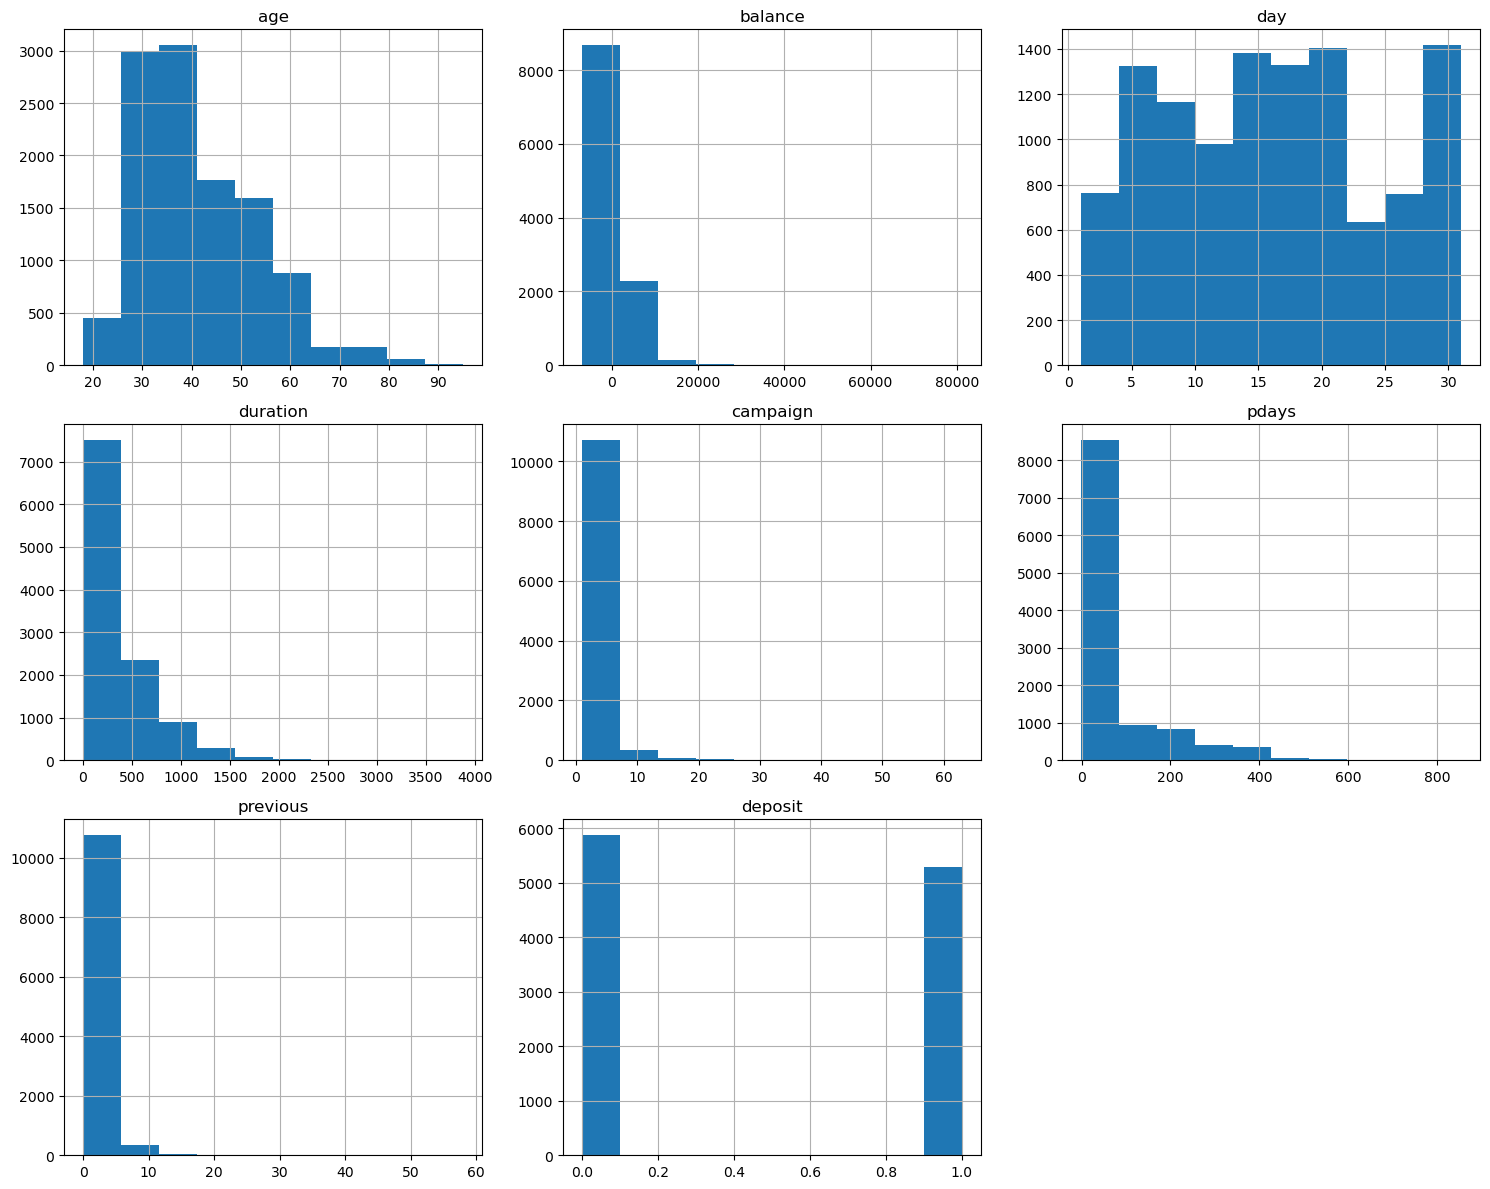

In [15]:
df[numerical_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()

1. balance is positively skewed here so tranformations can help later.
2. Duration and pdays are highly skewed so it is much required to improve here.
3. Campaign , age and previous features can be neglected to transform furthur.


In [16]:
# label encoding 
df["education"]=df["education"].map({
    "primary":0,
    "secondary":1,
     "tertiary":2,
     "unknown":-1})

df["loan"]=df["loan"].map({
    "no":0,
    "yes":1 })

In [17]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")


In [18]:
cat_cols=['job', 'marital', 'housing', 'default', 'contact','month', 'poutcome']
encoded=encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))
df=df.drop(cat_cols, axis=1)
df=pd.concat([df,encoded_df], axis=1)

In [19]:
df.head()

,age,education,balance,loan,day,duration,campaign,pdays,previous,deposit,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,1,2343,0,5,1042,1,-1,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,56,1,45,0,5,1467,1,-1,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,41,1,1270,0,5,1389,1,-1,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,55,1,2476,0,5,579,1,-1,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,54,2,184,0,5,673,2,-1,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


# Splitting train and test data 


In [20]:
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler


In [21]:
X=df.drop("deposit",axis=1)
y=df["deposit"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

 ^ We have split our data into 20% testing data and 80% training data to our model.

 ^ Now there are different scales so there is a need to balance them onto a similar scale so that features should not have great or less importance because of higher or lower numerical values.
 

In [23]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,f1_score,confusion_matrix,recall_score
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)
y_pred=lr.predict(X_test_scaled)
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

precision 0.8153241650294696
recall 0.7778819119025304
F1 score 0.7961630695443646
accuracy 0.8096730855351545
confusion_matrix [[978 188]
 [237 830]]


In [24]:
# cross validation for Hperparameter tuning 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
classifier=KNeighborsClassifier()
param_grid={"n_neighbors": [3,5,7,9,11,13]}
classifierCV=GridSearchCV(
    classifier,
    param_grid,
    cv=5
)
classifierCV.fit(X_train_scaled, y_train)
y_pred=classifierCV.predict(X_test_scaled)
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))



precision 0.8165548098434005
recall 0.6841611996251171
F1 score 0.744518103008669
accuracy 0.7756381549484997
confusion_matrix [[1002  164]
 [ 337  730]]


In [25]:
# KNN classifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score,recall_score
neigh=KNeighborsClassifier()
neigh.fit(X_train_scaled, y_train)
y_pred=neigh.predict(X_test_scaled)
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

precision 0.7976318622174381
recall 0.6944704779756327
F1 score 0.7424849699398798
accuracy 0.7698163905060457
confusion_matrix [[978 188]
 [326 741]]


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
classifier=DecisionTreeClassifier()
params={
    "max_depth":[3,5,7,9],
    "min_samples_split":[2,3,5,7],
    "min_samples_leaf":[2,3,4],
    "ccp_alpha":[0.0,0.01,0.001,0.1]
}
grid=GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5
)
grid.fit(X_train_scaled,y_train)
print(grid.best_params_)


{'ccp_alpha': 0.001, 'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [27]:
# Decision tree 
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier()
dtc.fit(X_train_scaled,y_train)
y_pred=dtc.predict(X_test_scaled)
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

recall 0.7722586691658857
F1 score 0.781042654028436
accuracy 0.7931034482758621
confusion_matrix [[947 219]
 [243 824]]


In [28]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(ccp_alpha=0.001, max_depth=9,min_samples_leaf=2, min_samples_split=2)
dtc.fit(X_train_scaled,y_train)
y_pred=dtc.predict(X_test_scaled)
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

recall 0.8481724461105904
F1 score 0.8178942611839133
accuracy 0.819525302283923
confusion_matrix [[925 241]
 [162 905]]


In [29]:
# SVM 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score,recall_score
svc=SVC()
svc.fit(X_train_scaled,y_train)
y_pred=svc.predict(X_test_scaled)
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))


recall 0.8331771321462043
F1 score 0.8281322775966465
accuracy 0.8347514554411106
confusion_matrix [[975 191]
 [178 889]]


# AFTER APPLYING EDA

In [33]:
df.drop(["day", "default_yes"],axis=1)
df["balance"]=np.log1p(df["balance"])
df["duration"]=np.log1p(df["duration"])
df["campaign"]=np.log1p(df["campaign"])
df["loan_burdun"]=(df["housing_yes"]+df["loan"])
df["long_call"]=(df["duration"]>300).astype(int)
df["frequent_contact"]=(df["campaign"]>5).astype(int)

In [34]:
df.drop(["housing_yes","loan"], axis=1)

,age,education,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,loan_burdun,long_call,frequent_contact
0,59,1,1.153779,5,1.122704,0.423036,-1,0,1,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0
1,56,1,0.945681,5,1.136309,0.423036,-1,0,1,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0
2,41,1,1.130666,5,1.134186,0.423036,-1,0,1,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0
3,55,1,1.155759,5,1.097435,0.423036,-1,0,1,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0
4,54,2,1.039509,5,1.104152,0.554618,-1,0,1,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,0,0.423036,20,1.057761,0.423036,-1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0,0
11158,39,1,1.107886,16,0.990318,0.672503,-1,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0
11159,32,1,0.909015,19,1.030009,0.554618,-1,0,0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0
11160,43,1,0.000000,8,0.786048,0.554618,172,5,0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0


In [38]:
from sklearn.impute import SimpleImputer
sm=SimpleImputer(strategy="mean")
df["balance"]=sm.fit_transform(df[["balance"]])

In [39]:
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler


In [40]:
X=df.drop("deposit",axis=1)
y=df["deposit"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

LOGISTIC REGRESSION

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,f1_score,confusion_matrix,recall_score
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)
y_pred=lr.predict(X_test_scaled)
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

precision 0.7930082796688133
recall 0.8078725398313027
F1 score 0.8003714020427113
accuracy 0.8074339453649798
confusion_matrix [[941 225]
 [205 862]]


#KNN

In [43]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
classifier=KNeighborsClassifier()
param_grid={"n_neighbors": [3,5,7,9,11,13]}
classifierCV=GridSearchCV(
    classifier,
    param_grid,
    cv=5
)
classifierCV.fit(X_train_scaled, y_train)
y_pred=classifierCV.predict(X_test_scaled)
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))


precision 0.7764830508474576
recall 0.6869728209934396
F1 score 0.7289905519641969
accuracy 0.7559337214509628
confusion_matrix [[955 211]
 [334 733]]


Decision Tree

In [45]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(ccp_alpha=0.001, max_depth=9,min_samples_leaf=2, min_samples_split=2)
dtc.fit(X_train_scaled,y_train)
y_pred=dtc.predict(X_test_scaled)
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

recall 0.8425492033739457
F1 score 0.8195077484047402
accuracy 0.8226600985221675
confusion_matrix [[938 228]
 [168 899]]


In [46]:
# SVM 
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score,recall_score
svc=SVC()
svc.fit(X_train_scaled,y_train)
y_pred=svc.predict(X_test_scaled)
print("recall",recall_score(y_test,y_pred))
print("F1 score",f1_score(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))


recall 0.8575445173383318
F1 score 0.8310626702997275
accuracy 0.8334079713390058
confusion_matrix [[946 220]
 [152 915]]


# overall recall scores and accuracy are improved in SVM, Decision Tree and Logistic Regression as per the problem statement.
